### model train after feature_store load

In [0]:
%run ./package

In [0]:
df = spark.read.format('delta').load('/mnt/jenny_mlops/preprocessing').withColumnRenamed("Churn_encode",'label')

In [0]:
display(df.summary())
#null값 없음

summary,SeniorCitizen,tenure,MonthlyCharges,customerID_encode,gender_encode,Partner_encode,Dependents_encode,PhoneService_encode,MultipleLines_encode,InternetService_encode,OnlineSecurity_encode,OnlineBackup_encode,DeviceProtection_encode,TechSupport_encode,StreamingTV_encode,StreamingMovies_encode,Contract_encode,PaperlessBilling_encode,PaymentMethod_encode,TotalCharges_encode,label
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
mean,0.1621468124378816,32.37114865824223,64.76169246059922,3521.0,0.495243504188556,0.4830327985233565,0.2995882436461735,0.09683373562402385,0.6155047564958115,0.7770836291353117,0.7200056793979838,0.7782195087320743,0.777225614084907,0.7235553031378674,0.8176913247195797,0.8212409484594633,0.6589521510719863,0.4077807752378248,1.3156325429504472,3037.2653698707936,0.2653698707936959
stddev,0.3686116056100135,24.559481023094442,30.090047097678482,2033.28330539549,0.5000128736471522,0.49974751071998735,0.4581101675100144,0.2957522317836351,0.6560390468441571,0.7788766677969745,0.7968850176117437,0.7784715900811064,0.7788261352139183,0.7958963708404075,0.7632122860654442,0.7617248206360178,0.8019433817739191,0.4914569240494065,1.1489068966766027,1989.7606183963026,0.44156130512194697
min,0,0,18.25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,0,9,35.5,1759.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1247.0,0.0
50%,0,29,70.35,3520.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,3008.0,0.0
75%,0,55,89.85,5281.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,4769.0,1.0
max,1,72,118.75,7042.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,3.0,6530.0,1.0


In [0]:
train, test = df.randomSplit([0.7, 0.3], seed = 42)
print("There are %d training examples and %d test examples." % (train.count(), test.count()))

There are 5036 training examples and 2007 test examples.


### mlflow

In [0]:
cols = train.drop('customerID_encode','label').columns
#index, label rm ->feature

xgb
             Train    Test
PR AUC      0.9771  0.6093
ROC AUC     0.9914  0.8216
F0.5 Score  0.9232  0.5760
F2 Score    0.9002  0.5412
Recall      0.8928  0.5306
Precision   0.9311  0.5886
Accuracy    0.9531  0.7877
                                        Validation Plots


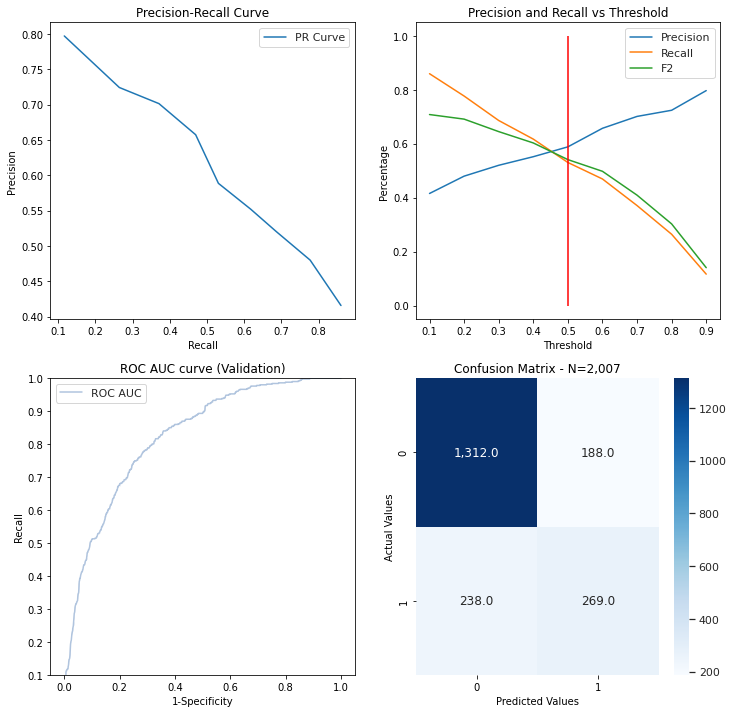

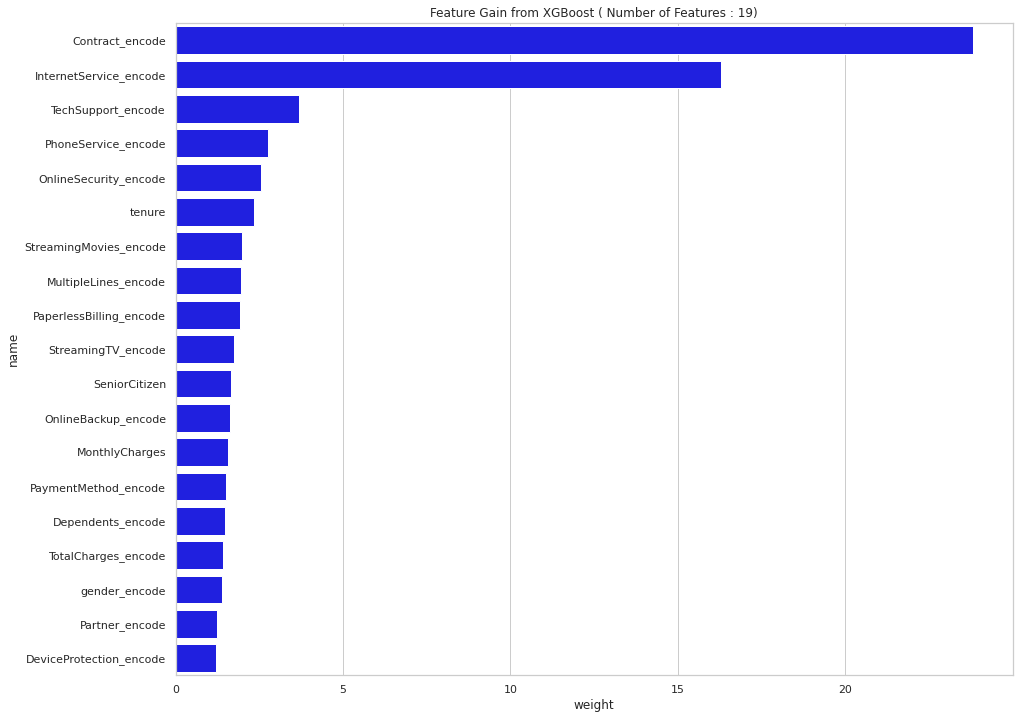

2023/06/14 08:45:56 INFO mlflow.spark: Inferring pip requirements by reloading the logged model from the databricks artifact repository, which can be time-consuming. To speed up, explicitly specify the conda_env or pip_requirements when calling log_model().


In [0]:
with mlflow.start_run(experiment_id ='2305299045478060', run_name='spark_mlops_xgboost', nested=True) as run:
    # SparkSession.builder.getOrCreate()
    from xgboost.spark import SparkXGBClassifier
    vec_assembler = VectorAssembler(inputCols=cols, outputCol="features", handleInvalid='keep')

    xgb_c = SparkXGBClassifier(seed=42,
                            features_Col="features",
                            label_Col="label",
                            )
    
    pipeline = Pipeline(stages=[vec_assembler,xgb_c])
    model = pipeline.fit(train)
    train_pre = model.transform(train)
    test_pre = model.transform(test)
    #metric
    results_pddf, fig = evaluate(train_pre, test_pre, "xgb")
    #importance_feature_plot
    feature_plot = feature_importance_plot(model,test_pre)

    #metric log
    for x, row in results_pddf.iterrows():
        for col in results_pddf.columns:
            name = (x + '_' + col).replace(' ', '_')
            mlflow.log_metric(name, row[col])

    #metric parameter
    param_map = model.stages[-1].extractParamMap()
    for param, value in param_map.items():
        if value is not None:
            mlflow.log_param(param.name, value)

    mlflow.spark.log_model(model, "model")
    mlflow.log_figure(fig, "plots/evaluate_plot.png")
    mlflow.log_figure(feature_plot, "plots/feature_importance.png")